In [1]:
import re
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path

import config
from gene_selectors import GeneSelector
from pipeline import data_prep, enrichment, plots
from pipeline.enrichment import gsea_run_dir, run_gsea_prerank
from viz_style import apply_style
apply_style()

In [15]:
dd = data_prep.load_disease_filtered() # Filter disease phenotype with OOD covariate distribution & too small samples sizes.
print(f'Final: {dd.Z_dis.shape[0]} samples, {len(np.unique(dd.dis_pheno))} phenotypes')

Final: 854 samples, 20 phenotypes


In [16]:
print(pd.Series(dd.dis_pheno).value_counts().to_string())

CAD_HF+                          112
Tuberculosis                     101
CAD_HF-                          100
ME/CFS                            90
Pancreatitis                      79
Pancreatic Cancer (Moore)         72
Pre-eclampsia                     59
Colorectal Cancer                 37
Lung Cancer                       30
Liver Cancer (Roskams-Hieter)     28
Esophagus Cancer (Chen)           25
Stomach Cancer                    24
MM                                17
Other Cancer                      16
HIV                               13
ICI-m                             11
ICI-treated Cancer                11
HIV + Tuberculosis                11
Liver Cancer (Chen)               10
MGUS                               8


## Ubiquity filter: target gene identification

Compute cross-disease ubiquity scores and identify which genes each condition zeros out in the GSEA ranking. Compare against known artifact-candidate families (ribo, OXPHOS, histone).

In [ ]:
FILTER_CONDITIONS = [
    {'ubiquity_thr': None,  'ubiquity_abs_z': 0.5, 'label': 'no_filter'},
    {'ubiquity_thr': 0.5,   'ubiquity_abs_z': 0.5, 'label': 'ubiq50_abs5'},
    {'ubiquity_thr': 0.6,   'ubiquity_abs_z': 0.5, 'label': 'ubiq60_abs5'},
    {'ubiquity_thr': 0.7,   'ubiquity_abs_z': 0.5, 'label': 'ubiq70_abs5'},
]

for cond in FILTER_CONDITIONS:
    cond['gsea_dir'] = gsea_run_dir(cond['ubiquity_thr'], cond['ubiquity_abs_z'])
    print(f"{cond['label']:15s} → {cond['gsea_dir'].relative_to(config.ROOT)}")

In [39]:
HISTONE_PAT = re.compile(r'^HIST[0-9]|^H[0-9][A-Z][A-Z0-9]|^H[0-9]-', re.I)
OXPHOS_PAT  = re.compile(r'^NDUF|^COX[0-9]|^ATP5|^UQCR|^SDHA|^SDHB|^SDHC|^SDHD')
RIBO_PAT    = re.compile(r'^RPS[0-9]|^RPL[0-9]|^RPLP')

def classify(s):
    if OXPHOS_PAT.match(s):  return 'oxphos'
    if RIBO_PAT.match(s):    return 'ribo'
    if HISTONE_PAT.match(s): return 'histone'
    return 'other'

gs = GeneSelector(dd.Z_dis, dd.dis_pheno, dd.gene_syms)
gene_cat = np.array([classify(s) for s in dd.gene_syms])

ubiq_rows = []
for cond in FILTER_CONDITIONS:
    thr = cond['ubiquity_thr']
    abs_z = cond['ubiquity_abs_z']
    if thr is None:
        ubiq_rows.append({'label': cond['label'], 'n_zeroed': 0,
                          'oxphos': 0, 'ribo': 0, 'histone': 0, 'other': 0})
        continue
    ubiq = gs.compute_ubiquity(abs_z_thr=abs_z)
    mask = ubiq >= thr
    ubiq_rows.append({
        'label':   cond['label'],
        'n_zeroed': int(mask.sum()),
        'oxphos':  int((mask & (gene_cat == 'oxphos')).sum()),
        'ribo':    int((mask & (gene_cat == 'ribo')).sum()),
        'histone': int((mask & (gene_cat == 'histone')).sum()),
        'other':   int((mask & (gene_cat == 'other')).sum()),
    })

ubiq_df = pd.DataFrame(ubiq_rows).set_index('label')
print('=== Genes zeroed out per filter condition ===')
print(ubiq_df.to_string())

n_oxphos = (gene_cat == 'oxphos').sum()
n_ribo   = (gene_cat == 'ribo').sum()
n_hist   = (gene_cat == 'histone').sum()
print(f'\nTotal genes in model: {len(dd.gene_syms)}')
print(f'Artifact-candidate families in model: oxphos={n_oxphos}, ribo={n_ribo}, histone={n_hist}')

=== Genes zeroed out per filter condition ===
             n_zeroed  oxphos  ribo  histone  other
label                                              
no_filter           0       0     0        0      0
ubiq50_abs5      1597      31    59       23   1484
ubiq60_abs5       523      15    27        4    477
ubiq70_abs5       131       6     9        2    114

Total genes in model: 20097
Artifact-candidate families in model: oxphos=111, ribo=100, histone=96


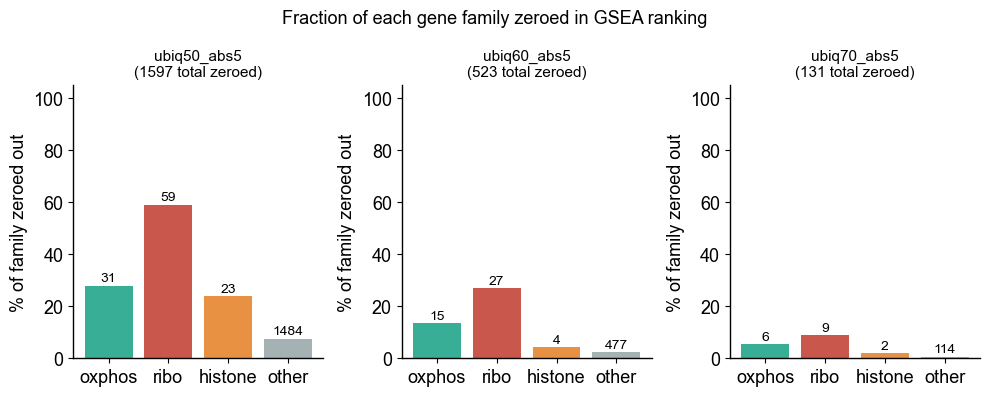

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(FILTER_CONDITIONS) - 1, figsize=(10, 4), sharey=False)
cats = ['oxphos', 'ribo', 'histone', 'other']
colors = ['#16a085', '#c0392b', '#e67e22', '#95a5a6']

for ax, cond in zip(axes, [c for c in FILTER_CONDITIONS if c['ubiquity_thr'] is not None]):
    row = ubiq_df.loc[cond['label']]
    totals = [row[c] for c in cats]
    totals_pct = [row[c] / max(
        (gene_cat == c).sum(), 1) * 100 for c in cats]
    bars = ax.bar(cats, totals_pct, color=colors, alpha=0.85, edgecolor='none')
    for bar, n in zip(bars, totals):
        if n > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    str(n), ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{cond['label']}\n({row['n_zeroed']} total zeroed)", fontsize=11)
    ax.set_ylabel('% of family zeroed out')
    ax.set_ylim(0, 105)

plt.suptitle('Fraction of each gene family zeroed in GSEA ranking', fontsize=13)
plt.tight_layout()
plt.show()

## GSEA run — all filter conditions

Run GSEA prerank for each condition and save to the corresponding directory. Skip if results already exist.

In [41]:
from pipeline.signatures import load_gsea

all_results = {}
unique_phenos = np.unique(dd.dis_pheno)

for cond in FILTER_CONDITIONS:
    label = cond['label']
    gsea_dir = cond['gsea_dir']
    thr = cond['ubiquity_thr']
    abs_z = cond['ubiquity_abs_z']

    existing = list(gsea_dir.glob('gsea_result_*.csv'))
    if existing:
        print(f"[{label}] loading {len(existing)} files from {gsea_dir.relative_to(config.ROOT)}")
        loaded = {}
        for ph in unique_phenos:
            df = load_gsea(ph, gsea_dir=gsea_dir)
            if df is not None:
                loaded[ph] = df
        all_results[label] = loaded
        print(f"  loaded: {len(loaded)}/{len(unique_phenos)} phenotypes")
        continue

    if thr is None:
        print(f"[{label}] no existing results found — run with ubiquity_thr=None first to generate baseline")
        all_results[label] = {}
        continue

    print(f"\n{'='*60}")
    print(f"[{label}] Running GSEA → {gsea_dir.relative_to(config.ROOT)}")
    print(f"{'='*60}")
    results = run_gsea_prerank(
        dd.Z_dis, dd.dis_pheno, dd.gene_syms,
        outdir=gsea_dir,
        ubiquity_thr=thr,
        ubiquity_abs_z=abs_z,
    )
    all_results[label] = results
    print(f"[{label}] Done — {len(results)} phenotypes written")

[no_filter] loading 22 files from Modeling/GSEA/no_filter
  loaded: 20/20 phenotypes
[ubiq50_abs5] loading 20 files from Modeling/GSEA/ubiq50_abs5
  loaded: 20/20 phenotypes
[ubiq60_abs5] loading 20 files from Modeling/GSEA/ubiq60_abs5
  loaded: 20/20 phenotypes
[ubiq70_abs5] loading 20 files from Modeling/GSEA/ubiq70_abs5
  loaded: 20/20 phenotypes


## GSEA run — with_rare (optional, side-by-side)

`dd.Z_dis` (used by every condition above) only carries scores for genes the
NormativeModelEngine fits (NBI/ZINBI/logistic) — the ~559 genes below
`low_det_thr`, handled separately by `RareEventScorer`, are zero-filled there
and invisible to GSEA. This cell builds an augmented Z matrix with those scores
embedded (`scoring.score_disease_with_rare`, in-memory only — `Z_disease.npy`
is never touched) and runs GSEA on it into its own `GSEA/with_rare/` folder, so
results stay directly comparable to `no_filter` without overwriting it. Opt-in:
run this cell only when you want that comparison.

In [ ]:
from pipeline import scoring

WITH_RARE_DIR = config.GSEA_DIR / 'with_rare'
existing = list(WITH_RARE_DIR.glob('gsea_result_*.csv'))

if existing:
    print(f"[with_rare] loading {len(existing)} files from {WITH_RARE_DIR.relative_to(config.ROOT)}")
    results_with_rare = {}
    for ph in unique_phenos:
        df = load_gsea(ph, gsea_dir=WITH_RARE_DIR)
        if df is not None:
            results_with_rare[ph] = df
    print(f"  loaded: {len(results_with_rare)}/{len(unique_phenos)} phenotypes")
else:
    Z_with_rare = scoring.score_disease_with_rare(dd)
    print(f"\n{'='*60}")
    print(f"[with_rare] Running GSEA → {WITH_RARE_DIR.relative_to(config.ROOT)}")
    print(f"{'='*60}")
    results_with_rare = run_gsea_prerank(
        Z_with_rare, dd.dis_pheno, dd.gene_syms,
        outdir=WITH_RARE_DIR,
        ubiquity_thr=None,
    )
    print(f"[with_rare] Done — {len(results_with_rare)} phenotypes written")

all_results['with_rare'] = results_with_rare

## Dotplots — save per condition

Save up/down dotplots for each filter condition into `{gsea_dir}/Figures/gsea_dotplot/`.

In [42]:
sample_sizes = {ph: int((dd.dis_pheno == ph).sum()) for ph in unique_phenos}

for cond in FILTER_CONDITIONS:
    label = cond['label']
    gsea_dir = cond['gsea_dir']
    fig_dir = gsea_dir / 'Figures' / 'gsea_dotplot'

    results = all_results.get(label, {})
    if not results:
        print(f"[{label}] no results — skipping plots")
        continue

    print(f"[{label}] saving dotplots → {fig_dir.relative_to(config.ROOT)}")
    plots.plot_gsea_dotplots(results, fig_dir=fig_dir, sample_sizes=sample_sizes)

[no_filter] saving dotplots → Modeling/GSEA/no_filter/Figures/gsea_dotplot
[CAD_HF+] GSEA Plots generated successfully.
[CAD_HF-] GSEA Plots generated successfully.
[Colorectal Cancer] GSEA Plots generated successfully.
[Esophagus Cancer (Chen)] GSEA Plots generated successfully.
[HIV] GSEA Plots generated successfully.
[HIV + Tuberculosis] GSEA Plots generated successfully.
[ICI-m] GSEA Plots generated successfully.
[ICI-treated Cancer] GSEA Plots generated successfully.
[Liver Cancer (Chen)] GSEA Plots generated successfully.
[Liver Cancer (Roskams-Hieter)] GSEA Plots generated successfully.
[Lung Cancer] GSEA Plots generated successfully.
[ME/CFS] GSEA Plots generated successfully.
[MGUS] GSEA Plots generated successfully.
[MM] GSEA Plots generated successfully.
[Other Cancer] GSEA Plots generated successfully.
[Pancreatic Cancer (Moore)] GSEA Plots generated successfully.
[Pancreatitis] GSEA Plots generated successfully.
[Pre-eclampsia] GSEA Plots generated successfully.
[Stomach C

## Cross-condition comparison

In [ ]:
import re as _re

ARTIFACT_PAT = _re.compile(
    r'histone|chromatin|nucleosome'
    r'|mitochond|oxidative phosph|electron transport|respiratory chain'
    r'|ribosom|rRNA|translation elongation|translation initiation',
    _re.IGNORECASE,
)


def summarise_results(results):
    """Summarise GSEA results dict {phenotype: DataFrame}.

    Returns DataFrame indexed by phenotype with columns:
      n_up, n_dn, n_total         — significant term counts by NES direction
      n_artifact, artifact_frac   — artifact-candidate terms (count and fraction of n_total)
    """
    rows = []
    for ph, df in results.items():
        df = df.copy()
        df['NES'] = pd.to_numeric(df['NES'], errors='coerce')
        n_up  = int((df['NES'] > 0).sum())
        n_dn  = int((df['NES'] < 0).sum())
        n_tot = n_up + n_dn
        n_art = int(df['Term'].str.contains(ARTIFACT_PAT, na=False).sum())
        rows.append({
            'phenotype':    ph,
            'n_up':         n_up,
            'n_dn':         n_dn,
            'n_total':      n_tot,
            'n_artifact':   n_art,
            'artifact_frac': round(n_art / n_tot, 3) if n_tot > 0 else 0.0,
        })
    return pd.DataFrame(rows).set_index('phenotype').sort_index()


summaries = {label: summarise_results(res) for label, res in all_results.items()}

print('=== Total significant terms per condition ===')
totals = pd.DataFrame({lbl: s['n_total'] for lbl, s in summaries.items()})
totals.loc['TOTAL'] = totals.sum()
print(totals.to_string())

print()
print('=== Artifact terms: count per condition ===')
arts_n = pd.DataFrame({lbl: s['n_artifact'] for lbl, s in summaries.items()})
arts_n.loc['TOTAL'] = arts_n.sum()
print(arts_n.to_string())

print()
print('=== Artifact terms: fraction of significant terms ===')
arts_f = pd.DataFrame({lbl: s['artifact_frac'] for lbl, s in summaries.items()})
arts_f.loc['MEAN'] = arts_f.mean()
print(arts_f.round(3).to_string())

print()
print('=== Change vs no_filter (delta n_total = condition - no_filter) ===')
ref = summaries.get('no_filter')
if ref is not None:
    non_ref = [lbl for lbl in summaries if lbl != 'no_filter']
    if non_ref:
        delta = pd.DataFrame({
            lbl: summaries[lbl]['n_total'] - ref['n_total']
            for lbl in non_ref
        })
        delta.loc['TOTAL'] = delta.sum()
        print(delta.to_string())


In [ ]:
import glob as _glob

DESEQ2_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_results'
_deseq_gsea = {}
for _f in sorted(_glob.glob(str(DESEQ2_DIR / 'gsea_result_*.csv'))):
    _ph = Path(_f).stem.replace('gsea_result_', '').replace('_', ' ')
    _deseq_gsea[_ph] = pd.read_csv(_f)

if _deseq_gsea:
    all_results['deseq2'] = _deseq_gsea
    print(f"Added 'deseq2' to all_results: {len(_deseq_gsea)} phenotypes")
else:
    print("No DESeq2 GSEA files found — run DESeq2 GSEA cells first")

print("Keys in all_results:", list(all_results.keys()))

summaries = {label: summarise_results(res) for label, res in all_results.items()}

print()
print('=== Total significant terms (including DESeq2) ===')
totals = pd.DataFrame({lbl: s['n_total'] for lbl, s in summaries.items()})
totals.loc['TOTAL'] = totals.sum()
print(totals.to_string())

print()
print('=== Artifact terms: count ===')
arts_n = pd.DataFrame({lbl: s['n_artifact'] for lbl, s in summaries.items()})
arts_n.loc['TOTAL'] = arts_n.sum()
print(arts_n.to_string())

print()
print('=== Artifact terms: fraction of significant terms ===')
arts_f = pd.DataFrame({lbl: s['artifact_frac'] for lbl, s in summaries.items()})
arts_f.loc['MEAN'] = arts_f.mean()
print(arts_f.round(3).to_string())


In [ ]:
import matplotlib.pyplot as plt

# Grouped bar: total sig terms per condition including deseq2
labels = list(summaries.keys())
phenos_u = sorted(set.union(*[set(s.index) for s in summaries.values()]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in [
    (axes[0], 'n_total',    'Total significant GSEA terms'),
    (axes[1], 'n_artifact', 'Artifact-candidate terms (ribo/OXPHOS)'),
]:
    x = np.arange(len(phenos_u))
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        vals = [summaries[label].get(ph, {}).get(col, 0)
                if ph in summaries[label].index else 0
                for ph in phenos_u]
        ax.bar(x + i * width, vals, width, label=label, alpha=0.85)
    ax.set_xticks(x + width * (len(labels) - 1) / 2)
    ax.set_xticklabels([p[:18] for p in phenos_u], rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Normative (filter conditions) vs DESeq2 — GSEA term counts', fontsize=13)
plt.tight_layout()
plt.show()


## PyDESeq2 Benchmark — within-study Disease vs HC

In [4]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from scipy.sparse import issparse

DESEQ2_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_results'
DESEQ2_DIR.mkdir(parents=True, exist_ok=True)
MP = config.MODELING_PARAMS


def deseq2_path(phenotype):
    stem = re.sub(r'[^A-Za-z0-9]+', '_', phenotype).strip('_')
    return DESEQ2_DIR / f'deseq2_{stem}.csv'


# Raw count extraction: prefer adata.raw, fall back to adata.X
_adata = dd.adata
if _adata.raw is not None:
    try:
        _raw_X = _adata.raw[:, _adata.var_names].X
        raw_counts_full = _raw_X.toarray() if issparse(_raw_X) else np.asarray(_raw_X)
    except Exception:
        raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
else:
    raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
raw_counts_full = np.round(raw_counts_full).astype(np.int64)

obs_names_list = _adata.obs_names.tolist()
obs2idx = {n: i for i, n in enumerate(obs_names_list)}
gene_ids = _adata.var_names.tolist()
id2sym_map = dict(zip(_adata.var_names, _adata.var['GeneName']))

name2pheno_ood = dict(zip(dd.dis_names, dd.dis_pheno))
unique_phenos_ood = sorted(np.unique(dd.dis_pheno))

deseq2_computed = {}

for phenotype in unique_phenos_ood:
    out_path = deseq2_path(phenotype)
    if out_path.exists():
        print(f'[{phenotype}] loading existing -> {out_path.name}')
        deseq2_computed[phenotype] = pd.read_csv(out_path)
        continue

    dis_names_ph = [n for n, ph in name2pheno_ood.items() if ph == phenotype]
    if len(dis_names_ph) < 2:
        print(f'[{phenotype}] skip: n_disease={len(dis_names_ph)} < 2')
        continue

    dis_obs = _adata.obs.loc[dis_names_ph]
    authors = dis_obs['Author'].unique().tolist()

    hc_mask = dd.is_hc & _adata.obs['Author'].isin(authors)
    hc_names_ph = _adata.obs_names[hc_mask].tolist()
    if len(hc_names_ph) < 2:
        print(f'[{phenotype}] skip: n_hc={len(hc_names_ph)} < 2 (authors={authors})')
        continue

    sample_names = dis_names_ph + hc_names_ph
    row_idx = [obs2idx[n] for n in sample_names]
    counts_arr = raw_counts_full[row_idx, :]
    counts_df = pd.DataFrame(counts_arr, index=sample_names, columns=gene_ids)
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) >= 10]

    condition = ['Disease'] * len(dis_names_ph) + ['HC'] * len(hc_names_ph)
    author_raw = (dis_obs['Author'].tolist() +
                  _adata.obs.loc[hc_names_ph, 'Author'].tolist())
    author_clean = [re.sub(r'[^A-Za-z0-9]+', '_', a).strip('_') for a in author_raw]

    metadata = pd.DataFrame({
        'condition': pd.Categorical(condition, categories=['HC', 'Disease']),
        'Author_clean': author_clean,
    }, index=sample_names)

    n_authors = len(set(author_clean))
    design = '~Author_clean + condition' if n_authors > 1 else '~condition'

    try:
        inference = DefaultInference(n_cpus=4)
        dds = DeseqDataSet(
            counts=counts_df,
            metadata=metadata,
            design=design,
            refit_cooks=True,
            inference=inference,
        )
        dds.deseq2()

        ds = DeseqStats(dds, contrast=['condition', 'Disease', 'HC'], inference=inference)
        ds.summary()

        res = ds.results_df.copy()
        res.index.name = 'ensg'
        res = res.reset_index()
        res['symbol'] = res['ensg'].map(id2sym_map).fillna(res['ensg'])

        res.to_csv(out_path, index=False)
        deseq2_computed[phenotype] = res

        n_sig = int((res['padj'].dropna() < 0.05).sum())
        print(f'[{phenotype}] n_dis={len(dis_names_ph)} n_hc={len(hc_names_ph)} '
              f'design={repr(design)}  sig={n_sig}')
    except Exception as e:
        print(f'[{phenotype}] ERROR -- {e}')

print(f'Done: {len(deseq2_computed)} / {len(unique_phenos_ood)} phenotypes computed')


[CAD_HF+] loading existing -> deseq2_CAD_HF.csv
[CAD_HF-] loading existing -> deseq2_CAD_HF.csv
[Colorectal Cancer] loading existing -> deseq2_Colorectal_Cancer.csv
[Esophagus Cancer (Chen)] loading existing -> deseq2_Esophagus_Cancer_Chen.csv
[HIV] loading existing -> deseq2_HIV.csv
[HIV + Tuberculosis] loading existing -> deseq2_HIV_Tuberculosis.csv
[ICI-m] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[ICI-treated Cancer] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[Liver Cancer (Chen)] loading existing -> deseq2_Liver_Cancer_Chen.csv
[Liver Cancer (Roskams-Hieter)] loading existing -> deseq2_Liver_Cancer_Roskams_Hieter.csv
[Lung Cancer] loading existing -> deseq2_Lung_Cancer.csv
[ME/CFS] loading existing -> deseq2_ME_CFS.csv
[MGUS] loading existing -> deseq2_MGUS.csv
[MM] loading existing -> deseq2_MM.csv
[Other Cancer] loading existing -> deseq2_Other_Cancer.csv
[Pancreatic Cancer (Moore)] loading existing -> deseq2_Pancreatic_Cancer_Moore.csv
[Pancreatitis] loading existi

## DESeq2 Benchmark GSEA
**Output**: `Modeling/Benchmark/deseq2_results/gsea_result_{phenotype}.csv` and dotplots in `Figures/gsea_dotplot/`.

In [ ]:
import gseapy as gp

# Requires deseq2_computed and deseq2_path() from the PyDESeq2 cell above.
GSEA_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_gsea'

deseq2_results = {}
all_phenos_for_gsea = list(deseq2_computed.keys()) if deseq2_computed else unique_phenos_ood

for phenotype in all_phenos_for_gsea:
    if phenotype in deseq2_computed:
        res_df = deseq2_computed[phenotype].copy()
    else:
        path = deseq2_path(phenotype)
        if not path.exists():
            print(f'[{phenotype}] no DESeq2 result -- skip GSEA')
            continue
        res_df = pd.read_csv(path)

    out_csv = GSEA_DIR / f"gsea_result_{phenotype.replace('/', '_')}.csv"
    if out_csv.exists():
        print(f'[{phenotype}] loading existing GSEA')
        deseq2_results[phenotype] = pd.read_csv(out_csv)
        continue

    res_df['stat'] = res_df['stat'].fillna(0.0)
    res_df['abs_stat'] = res_df['stat'].abs()
    res_df = (res_df.sort_values('abs_stat', ascending=False)
                    .drop_duplicates('symbol')
                    .drop(columns='abs_stat'))

    rnk = (res_df[['symbol', 'stat']]
           .rename(columns={'symbol': 'gene', 'stat': 'score'})
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

    try:
        res = gp.prerank(
            rnk=rnk, gene_sets=MP['gsea_gene_sets'], outdir=None,
            min_size=10, max_size=500,
            permutation_num=MP['gsea_perm'], seed=MP['gsea_seed'], verbose=False)
        sig = res.res2d[res.res2d['FDR q-val'] < MP['gsea_fdr_thr']].copy()
        sig.to_csv(out_csv, index=False)
        deseq2_results[phenotype] = sig
        sig['NES'] = pd.to_numeric(sig['NES'], errors='coerce')
        n_up = int((sig['NES'] > 0).sum())
        n_dn = int((sig['NES'] < 0).sum())
        print(f'[{phenotype}] {len(sig):4d} sig  (NES>0: {n_up:3d}  NES<0: {n_dn:3d})')
    except Exception as e:
        print(f'[{phenotype}] GSEA ERROR -- {e}')

print(f'Done: {len(deseq2_results)} phenotypes with GSEA results')


2026-06-29 16:56:23,443 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-29 16:56:41,216 [WARNING] Duplicated values found in preranked stats: 0.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[CAD_HF+]  596 sig  (NES>0: 215  NES<0: 381)


2026-06-29 16:56:57,162 [WARNING] Duplicated values found in preranked stats: 1.05% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[CAD_HF-]  596 sig  (NES>0: 215  NES<0: 381)


2026-06-29 16:57:11,552 [WARNING] Duplicated values found in preranked stats: 0.54% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


...

[Pancreatitis]   50 sig  (NES>0:  45  NES<0:   5)


2026-06-29 17:00:07,080 [WARNING] Duplicated values found in preranked stats: 0.98% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[Pre-eclampsia]   54 sig  (NES>0:  46  NES<0:   8)


2026-06-29 17:00:21,247 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


[Stomach Cancer]  437 sig  (NES>0:  27  NES<0: 410)
[Tuberculosis]  436 sig  (NES>0: 377  NES<0:  59)
Done: 18 phenotypes with GSEA results


In [8]:
deseq2_fig_dir = GSEA_DIR / 'gsea_dotplot'
plots.plot_gsea_dotplots(deseq2_results, fig_dir=deseq2_fig_dir)

[CAD_HF+] GSEA Plots generated successfully.
[CAD_HF-] GSEA Plots generated successfully.
[Colorectal Cancer] GSEA Plots generated successfully.
[Esophagus Cancer (Chen)] GSEA Plots generated successfully.
[HIV] GSEA Plots generated successfully.
[HIV + Tuberculosis] GSEA Plots generated successfully.
[Liver Cancer (Chen)] GSEA Plots generated successfully.
[Liver Cancer (Roskams-Hieter)] GSEA Plots generated successfully.
[Lung Cancer] GSEA Plots generated successfully.
[ME/CFS] GSEA Plots generated successfully.
[MGUS] GSEA Plots generated successfully.
[MM] GSEA Plots generated successfully.
[Other Cancer] GSEA Plots generated successfully.
[Pancreatic Cancer (Moore)] GSEA Plots generated successfully.
[Pancreatitis] GSEA Plots generated successfully.
[Pre-eclampsia] GSEA Plots generated successfully.
[Stomach Cancer] GSEA Plots generated successfully.
[Tuberculosis] GSEA Plots generated successfully.


## Normative vs DESeq2 — Descriptive Pathway-Level Comparison

In [18]:
import glob, re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

norm_dir  = config.GSEA_DIR / 'no_filter'
deseq_dir = config.MODELING_DIR / 'Benchmark' / 'deseq2_results'


def load_all(directory):
    out = {}
    for f in glob.glob(str(directory / 'gsea_result_*.csv')):
        ph = Path(f).stem.replace('gsea_result_', '').replace('_', ' ')
        df = pd.read_csv(f)
        df['NES'] = pd.to_numeric(df['NES'], errors='coerce')
        out[ph] = df
    return out


norm_res  = load_all(norm_dir)
deseq_res = load_all(deseq_dir)
common    = sorted(set(norm_res) & set(deseq_res))

rows = []
for ph in common:
    n = norm_res[ph].copy()
    d = deseq_res[ph].copy()

    n_terms = set(n['Term'])
    d_terms = set(d['Term'])
    shared  = n_terms & d_terms
    jac = len(shared) / len(n_terms | d_terms) if (n_terms | d_terms) else 0

    both = (n.set_index('Term')['NES'].rename('n')
             .to_frame().join(d.set_index('Term')['NES'].rename('d'))).dropna()
    agree = int(((both['n'] * both['d']) > 0).sum())
    pct_agree = agree / max(len(both), 1)

    n_up  = int((n['NES'] > 0).sum());  n_dn  = int((n['NES'] < 0).sum())
    d_up  = int((d['NES'] > 0).sum());  d_dn  = int((d['NES'] < 0).sum())

    rows.append({
        'phenotype':     ph,
        'n_norm':        len(n),
        'n_deseq':       len(d),
        'jaccard':       round(jac, 3),
        'pct_agree':     round(pct_agree * 100, 1),
        'n_shared':      len(shared),
        'norm_up_pct':   round(n_up / max(len(n), 1) * 100, 1),
        'norm_dn_pct':   round(n_dn / max(len(n), 1) * 100, 1),
        'deseq_up_pct':  round(d_up / max(len(d), 1) * 100, 1),
        'deseq_dn_pct':  round(d_dn / max(len(d), 1) * 100, 1),
        'norm_only':     len(n_terms - d_terms),
        'deseq_only':    len(d_terms - n_terms),
    })

cdf = pd.DataFrame(rows).set_index('phenotype').sort_values('jaccard')

print(cdf[['n_norm', 'n_deseq', 'jaccard', 'pct_agree',
           'norm_up_pct', 'deseq_up_pct']].round(1).to_string())
print()
print(f'Mean Jaccard        : {cdf.jaccard.mean():.3f}')
print(f'Mean NES agree %    : {cdf.pct_agree.mean():.1f}%')
print(f'Mean NES>0 norm  %  : {cdf.norm_up_pct.mean():.1f}%')
print(f'Mean NES>0 deseq %  : {cdf.deseq_up_pct.mean():.1f}%')


                               n_norm  n_deseq  jaccard  pct_agree  norm_up_pct  deseq_up_pct
phenotype                                                                                    
Pre-eclampsia                     230       54      0.0      100.0          0.9          85.2
ME CFS                            169       98      0.0      100.0          0.0           8.2
MGUS                              107      188      0.0      100.0         86.0          29.3
Liver Cancer (Chen)               625      107      0.0       48.1         27.4          83.2
Esophagus Cancer (Chen)           683      127      0.1       93.5         21.7          69.3
Pancreatitis                      263       50      0.1        0.0         10.3          90.0
HIV                               482       70      0.1      100.0         90.0          24.3
Pancreatic Cancer (Moore)         560      130      0.1       26.2         42.5          96.9
Liver Cancer (Roskams-Hieter)     217      287      0.1     

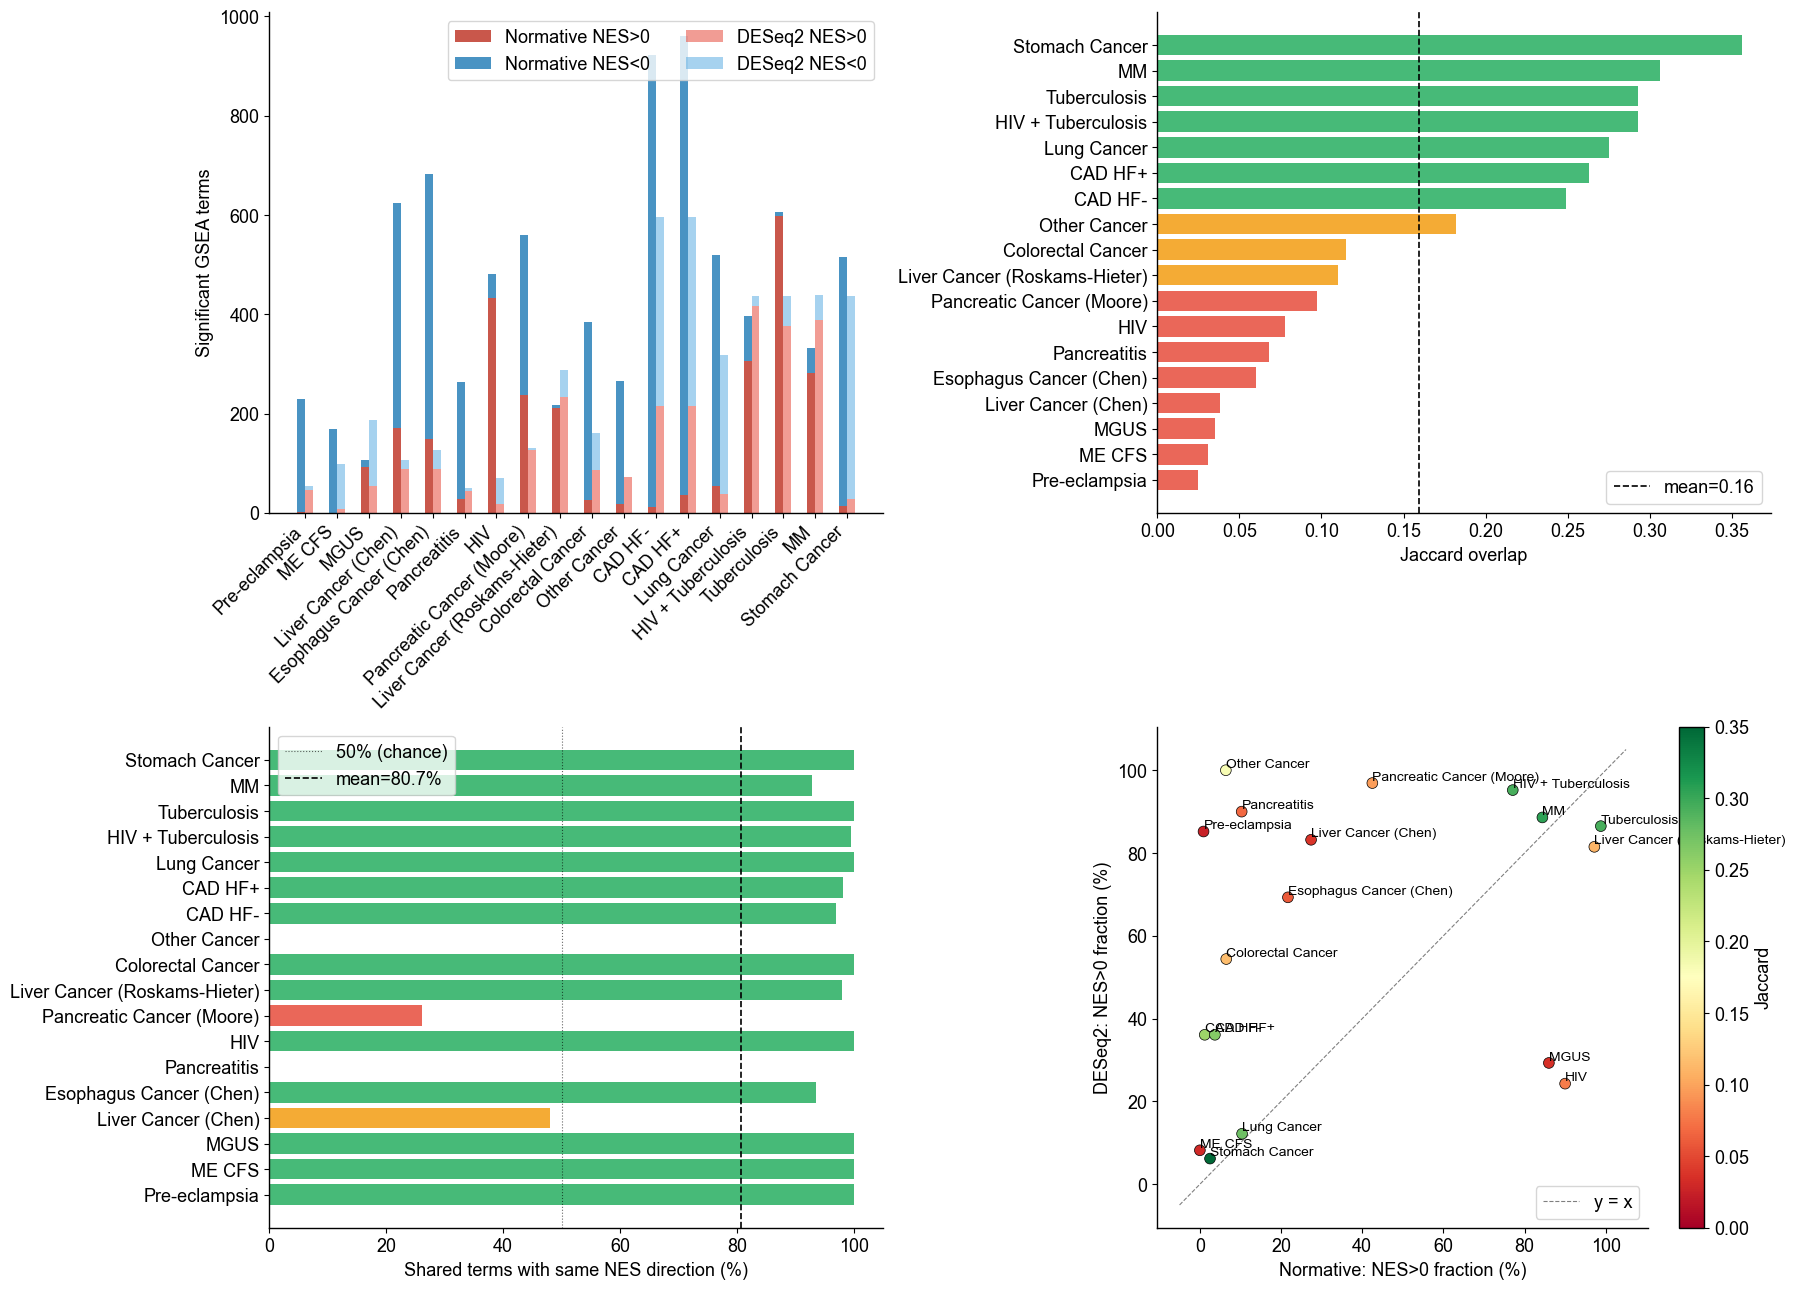

In [19]:
ph_labels = cdf.index
x = np.arange(len(cdf))
fig = plt.figure(figsize=(18, 13))
gs_fig = gridspec.GridSpec(2, 2, figure=fig)

# ── Panel A: Term count (stacked: UP / DOWN) ──────────────────────────
ax = fig.add_subplot(gs_fig[0, 0])
norm_up = cdf['n_norm'] * cdf['norm_up_pct'] / 100
norm_dn = cdf['n_norm'] * cdf['norm_dn_pct'] / 100
deseq_up = cdf['n_deseq'] * cdf['deseq_up_pct'] / 100
deseq_dn = cdf['n_deseq'] * cdf['deseq_dn_pct'] / 100

w = 0.25
ax.bar(x - w/2, norm_up,  w, color='#c0392b', alpha=0.85, label='Normative NES>0')
ax.bar(x - w/2, norm_dn,  w, bottom=norm_up, color='#2980b9', alpha=0.85, label='Normative NES<0')
ax.bar(x + w/2, deseq_up, w, color='#e74c3c', alpha=0.55, label='DESeq2 NES>0')
ax.bar(x + w/2, deseq_dn, w, bottom=deseq_up, color='#5dade2', alpha=0.55, label='DESeq2 NES<0')
ax.set_xticks(x); ax.set_xticklabels(ph_labels, rotation=45, ha='right')
ax.set_ylabel('Significant GSEA terms')
ax.legend(ncol=2)

# ── Panel B: Jaccard per phenotype ────────────────────────────────────
ax = fig.add_subplot(gs_fig[0, 1])
colors = ['#e74c3c' if j < 0.1 else '#f39c12' if j < 0.2 else '#27ae60'
          for j in cdf['jaccard']]
ax.barh(ph_labels, cdf['jaccard'], color=colors, alpha=0.85)
ax.axvline(cdf['jaccard'].mean(), color='black', linewidth=1.2,
           linestyle='--', label=f'mean={cdf.jaccard.mean():.2f}')
ax.set_xlabel('Jaccard overlap')
ax.legend()

# ── Panel C: NES sign agreement % ─────────────────────────────────────
ax = fig.add_subplot(gs_fig[1, 0])
colors2 = ['#e74c3c' if p < 30 else '#f39c12' if p < 60 else '#27ae60'
           for p in cdf['pct_agree']]
ax.barh(ph_labels, cdf['pct_agree'], color=colors2, alpha=0.85)
ax.axvline(50, color='black', linewidth=0.8, linestyle=':', alpha=0.6, label='50% (chance)')
ax.axvline(cdf['pct_agree'].mean(), color='black', linewidth=1.2,
           linestyle='--', label=f'mean={cdf.pct_agree.mean():.1f}%')
ax.set_xlabel('Shared terms with same NES direction (%)')
ax.legend()

# ── Panel D: NES>0 fraction comparison ────────────────────────────────
ax = fig.add_subplot(gs_fig[1, 1])
ax.scatter(cdf['norm_up_pct'], cdf['deseq_up_pct'], s=60,
           c=cdf['jaccard'], cmap='RdYlGn', vmin=0, vmax=0.35,
           edgecolors='black', linewidths=0.5, zorder=3)
for ph, row in cdf.iterrows():
    ax.annotate(ph, (row['norm_up_pct'], row['deseq_up_pct']), ha='left', va='bottom')
lo = min(cdf['norm_up_pct'].min(), cdf['deseq_up_pct'].min()) - 5
hi = max(cdf['norm_up_pct'].max(), cdf['deseq_up_pct'].max()) + 5
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8, alpha=0.5, label='y = x')
sc = ax.scatter([], [], c=[], cmap='RdYlGn', vmin=0, vmax=0.35)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn',
             norm=plt.Normalize(0, 0.35)), ax=ax, label='Jaccard')
ax.set_xlabel('Normative: NES>0 fraction (%)')
ax.set_ylabel('DESeq2: NES>0 fraction (%)')
ax.legend()

plt.tight_layout()
plt.show()